# Part 1 — Link analysis: PageRank, HITS, eigenvalues

**Course:** ECE328 Information Retrieval — University of Thessaly  
**Author:** Nikos Mavros (AEM 03741)

Four sub-parts:

- **1A** Personalised PageRank on a 14-node undirected graph, damping $a=0.65$, teleport vector concentrated on node 14.
- **1B** PageRank on an 8-node directed graph for $a\in\{0.55, 0.65, 0.75, 0.85, 0.95\}$, plus pairwise Kendall $\tau$ between the five rankings.
- **1C** HITS on a third 8-node directed graph: authorities matrix $A^\top A$, hubs matrix $A A^\top$, and the principal eigenvectors of each.
- **1D** Eigenvalues of the Google matrix on the 1A graph at $a=0.85$, before and after adding five new edges.

**Software:** Python 3, with `networkx` (graph data structures and PageRank/HITS), `numpy` (linear algebra), `scipy.stats.kendalltau`, `matplotlib`, and `pandas`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import kendalltau
from pathlib import Path

FIG_DIR = Path('../results/figures')
TBL_DIR = Path('../results/tables')
for d in (FIG_DIR, TBL_DIR):
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(42)  # for reproducible graph layouts

---
## 1A — Personalised PageRank on the 14-node graph

The graph is undirected with 14 nodes labelled 1..14 and the following 22 edges (as read from the assignment figure).

In [2]:
edges_14 = [
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3),
    (3, 4),
    (4, 5), (4, 6), (4, 7),
    (5, 10),
    (6, 7), (6, 8), (6, 9),
    (7, 9),
    (8, 9),
    (10, 11), (10, 12),
    (11, 13), (11, 14),
    (12, 13), (12, 14),
    (13, 14),
]

G14 = nx.Graph()
G14.add_nodes_from(range(1, 15))
G14.add_edges_from(edges_14)
print(f'Nodes: {G14.number_of_nodes()}   Edges: {G14.number_of_edges()}')
print('Degrees:')
for v, d in sorted(G14.degree, key=lambda x: -x[1]):
    print(f'  node {v:2d}  deg = {d}')

Nodes: 14   Edges: 22
Degrees:
  node  4  deg = 5
  node  1  deg = 4
  node  6  deg = 4
  node  3  deg = 3
  node  5  deg = 3
  node  7  deg = 3
  node  9  deg = 3
  node 10  deg = 3
  node 11  deg = 3
  node 12  deg = 3
  node 13  deg = 3
  node 14  deg = 3
  node  2  deg = 2
  node  8  deg = 2


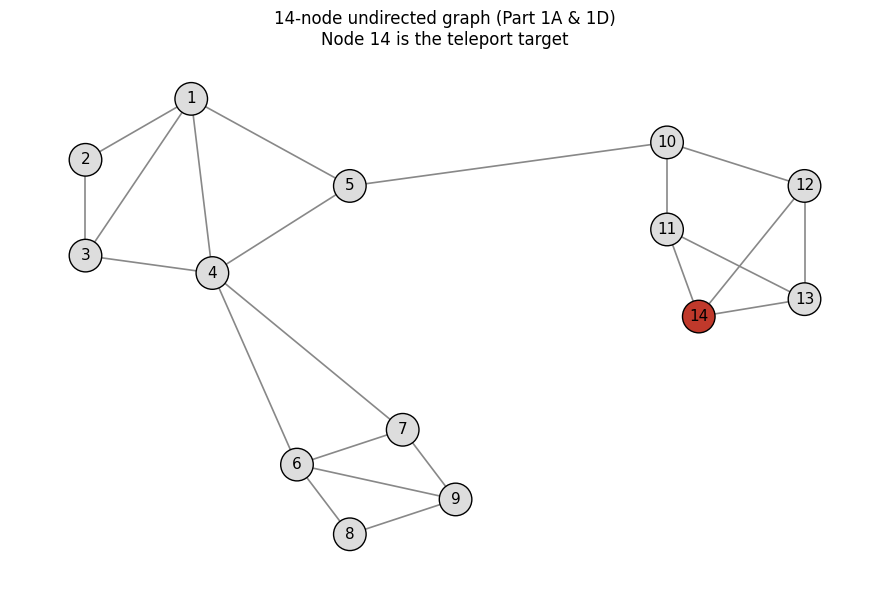

In [3]:
# Plot the graph using a layout that roughly matches the assignment's diagram
pos14 = {
    1: (1.0, 5.0),
    2: (0.0, 4.3),
    3: (0.0, 3.2),
    4: (1.2, 3.0),
    5: (2.5, 4.0),
    6: (2.0, 0.8),
    7: (3.0, 1.2),
    8: (2.5, 0.0),
    9: (3.5, 0.4),
    10: (5.5, 4.5),
    11: (5.5, 3.5),
    12: (6.8, 4.0),
    13: (6.8, 2.7),
    14: (5.8, 2.5),
}

fig, ax = plt.subplots(figsize=(9, 6))
node_colors = ['#c0392b' if v == 14 else '#dddddd' for v in G14.nodes()]
nx.draw_networkx_edges(G14, pos14, ax=ax, edge_color='#888', width=1.2)
nx.draw_networkx_nodes(G14, pos14, ax=ax, node_color=node_colors,
                       edgecolors='black', node_size=550)
nx.draw_networkx_labels(G14, pos14, ax=ax, font_size=11)
ax.set_title('14-node undirected graph (Part 1A & 1D)\nNode 14 is the teleport target', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1a_graph.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1a_graph.png', dpi=160, bbox_inches='tight')
plt.show()

In [4]:
# Personalisation vector v: 50% mass on node 14, the remaining 50% spread
# uniformly across the other 13 nodes (i.e. 0.5 / 13 ~= 3.846% each).
ALPHA_1A = 0.65

personalization = {v: (0.5 / 13.0) for v in G14.nodes()}
personalization[14] = 0.5

# Sanity check: vector sums to 1.0
assert abs(sum(personalization.values()) - 1.0) < 1e-12

pr_1a = nx.pagerank(G14, alpha=ALPHA_1A,
                    personalization=personalization,
                    tol=1e-10, max_iter=1000)

df_1a = (pd.DataFrame(
            [(v, pr_1a[v], G14.degree(v)) for v in G14.nodes()],
            columns=['node', 'pagerank', 'degree'])
         .sort_values('pagerank', ascending=False)
         .reset_index(drop=True))
df_1a['rank'] = df_1a.index + 1
df_1a = df_1a[['rank', 'node', 'pagerank', 'degree']]
df_1a.to_csv(TBL_DIR / 'p1a_pagerank.csv', index=False)
df_1a

,rank,node,pagerank,degree
0,1,14,0.245228,3
1,2,13,0.112457,3
2,3,12,0.105837,3
3,4,11,0.105837,3
4,5,10,0.068662,3
5,6,4,0.054080,5
6,7,1,0.047558,4
7,8,6,0.046180,4
8,9,5,0.043097,3
9,10,9,0.038346,3


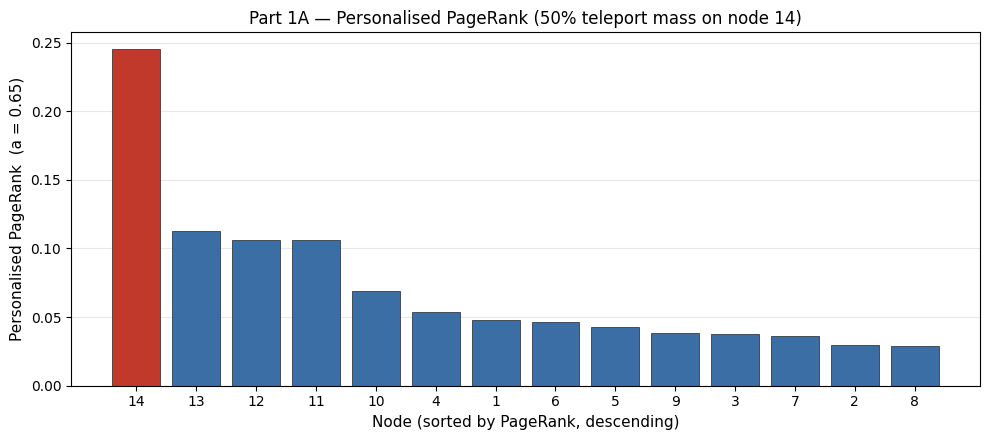

In [5]:
# Bar chart of the personalised PageRank values
fig, ax = plt.subplots(figsize=(10, 4.5))
order = df_1a['node'].tolist()
values = df_1a['pagerank'].tolist()
bar_colors = ['#c0392b' if v == 14 else '#3a6ea5' for v in order]
ax.bar(range(len(order)), values, color=bar_colors, edgecolor='black', linewidth=0.4)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([str(v) for v in order], fontsize=10)
ax.set_xlabel('Node (sorted by PageRank, descending)', fontsize=11)
ax.set_ylabel(f'Personalised PageRank  (a = {ALPHA_1A})', fontsize=11)
ax.set_title('Part 1A — Personalised PageRank (50% teleport mass on node 14)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1a_pagerank_bar.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1a_pagerank_bar.png', dpi=160, bbox_inches='tight')
plt.show()

**Observations.**

Node 14 ends up at the top of the ranking by a clear margin — unsurprising, since the teleport vector concentrates 50% of its probability mass there at every restart. Its closest neighbours in the right-hand cluster (11, 12, 13, all directly connected to 14) are pulled up next, because random walks that arrive on node 14 then propagate to them.

Node 10 inherits some of that mass too, since it sits at the boundary between the right cluster and the rest of the graph (connected to 11 and 12). Below 10, the ranks fall off as we move further from node 14 in graph distance: nodes in the central cluster (1, 4, 5) outrank the bottom cluster (6, 7, 8, 9), which is the most distant region from the teleport target.

The personalisation vector dominates the ranking far more than topology: in standard (uniform-teleport) PageRank, well-connected hub nodes like 4 (degree 5) and 1 (degree 4) would top the list, but here they are pushed below 11/12/13 because the teleport flow swamps the topological signal.

---
## 1B — Damping factor sweep on an 8-node directed graph

The graph is directed with nodes 0..7 and 13 edges (as read from the assignment figure).

In [6]:
edges_8_directed = [
    (0, 1), (0, 6), (0, 7),
    (1, 2), (2, 1),       # bidirectional 1<->2
    (1, 7),
    (2, 7),
    (3, 5), (3, 7),
    (4, 5),
    (5, 6), (6, 5),       # bidirectional 5<->6
    (7, 6),
]

G8 = nx.DiGraph()
G8.add_nodes_from(range(8))
G8.add_edges_from(edges_8_directed)
print(f'Nodes: {G8.number_of_nodes()}   Edges: {G8.number_of_edges()}')

Nodes: 8   Edges: 13


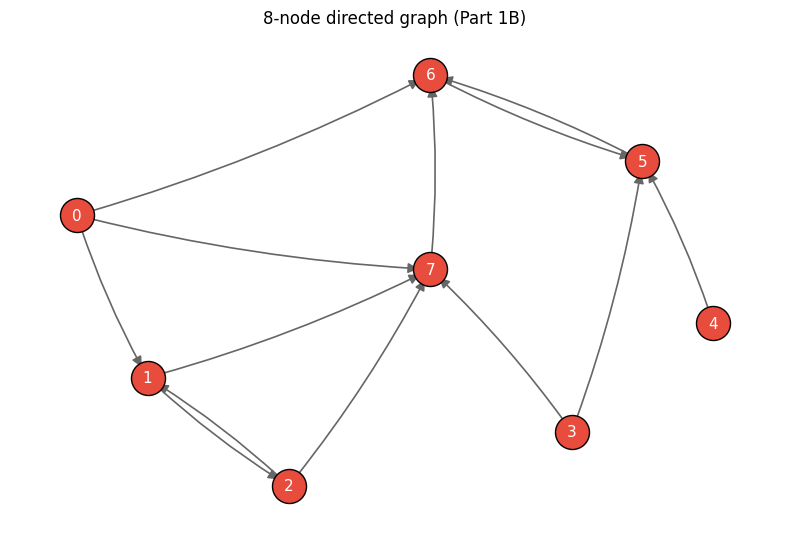

In [7]:
pos8 = {
    0: (0.0, 2.5),
    1: (0.5, 1.0),
    2: (1.5, 0.0),
    3: (3.5, 0.5),
    4: (4.5, 1.5),
    5: (4.0, 3.0),
    6: (2.5, 3.8),
    7: (2.5, 2.0),
}
fig, ax = plt.subplots(figsize=(8, 5.5))
nx.draw_networkx_edges(G8, pos8, ax=ax, edge_color='#666',
                       arrows=True, arrowsize=15, width=1.2,
                       connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(G8, pos8, ax=ax, node_color='#e74c3c',
                       edgecolors='black', node_size=600)
nx.draw_networkx_labels(G8, pos8, ax=ax, font_size=11, font_color='white')
ax.set_title('8-node directed graph (Part 1B)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1b_graph.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1b_graph.png', dpi=160, bbox_inches='tight')
plt.show()

In [8]:
ALPHAS = [0.55, 0.65, 0.75, 0.85, 0.95]

# Compute PageRank at each damping factor
pr_by_alpha = {}
for a in ALPHAS:
    pr_by_alpha[a] = nx.pagerank(G8, alpha=a, tol=1e-12, max_iter=2000)

# Build a tidy DataFrame: rows are nodes, columns are alphas
df_1b = pd.DataFrame(pr_by_alpha)
df_1b.index.name = 'node'
df_1b.columns = [f'a={a:.2f}' for a in ALPHAS]
df_1b.to_csv(TBL_DIR / 'p1b_pagerank_by_alpha.csv')
df_1b.round(4)

,a=0.55,a=0.65,a=0.75,a=0.85,a=0.95
node,,,,,
0,0.0562,0.0438,0.0312,0.0188,0.0063
1,0.0887,0.0754,0.0591,0.0391,0.0145
2,0.0807,0.0683,0.0534,0.0354,0.0131
3,0.0562,0.0438,0.0312,0.0188,0.0063
4,0.0562,0.0438,0.0312,0.0188,0.0063
5,0.2554,0.2930,0.3383,0.3932,0.4605
6,0.2778,0.3179,0.3625,0.4124,0.4688
7,0.1286,0.1141,0.0930,0.0637,0.0243


C:\Users\nickb\AppData\Local\Temp\ipykernel_6844\2344175121.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


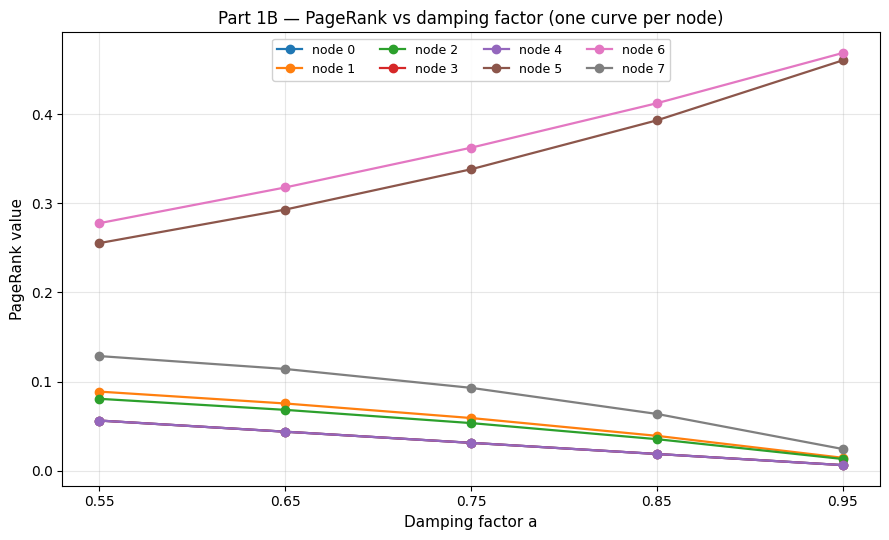

In [9]:
# Single plot with 8 curves (one per node), x-axis = damping, y-axis = PageRank
fig, ax = plt.subplots(figsize=(9, 5.5))
cmap = plt.cm.get_cmap('tab10', 10)
for v in sorted(G8.nodes()):
    y = [pr_by_alpha[a][v] for a in ALPHAS]
    ax.plot(ALPHAS, y, marker='o', linewidth=1.6, color=cmap(v),
            label=f'node {v}')
ax.set_xlabel('Damping factor a', fontsize=11)
ax.set_ylabel('PageRank value', fontsize=11)
ax.set_title('Part 1B — PageRank vs damping factor (one curve per node)',
             fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(ncol=4, loc='upper center', fontsize=9, framealpha=0.9)
ax.set_xticks(ALPHAS)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1b_curves.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1b_curves.png', dpi=160, bbox_inches='tight')
plt.show()

In [10]:
# Pairwise Kendall tau between rankings produced at each alpha.
# Convert PageRank dicts -> ranking vectors (lower rank number = higher PR)
def pr_to_rank_vector(pr_dict, nodes):
    sorted_nodes = sorted(nodes, key=lambda v: -pr_dict[v])
    rank = {v: i + 1 for i, v in enumerate(sorted_nodes)}
    return np.array([rank[v] for v in nodes])

nodes = sorted(G8.nodes())
rank_vectors = {a: pr_to_rank_vector(pr_by_alpha[a], nodes) for a in ALPHAS}

tau_matrix = np.zeros((len(ALPHAS), len(ALPHAS)))
p_matrix = np.zeros_like(tau_matrix)
for i, ai in enumerate(ALPHAS):
    for j, aj in enumerate(ALPHAS):
        tau, p = kendalltau(rank_vectors[ai], rank_vectors[aj])
        tau_matrix[i, j] = tau
        p_matrix[i, j] = p

tau_df = pd.DataFrame(tau_matrix,
                      index=[f'a={a:.2f}' for a in ALPHAS],
                      columns=[f'a={a:.2f}' for a in ALPHAS])
tau_df.to_csv(TBL_DIR / 'p1b_kendall_tau.csv')
tau_df.round(4)

,a=0.55,a=0.65,a=0.75,a=0.85,a=0.95
a=0.55,1.0,1.0,1.0,1.0,1.0
a=0.65,1.0,1.0,1.0,1.0,1.0
a=0.75,1.0,1.0,1.0,1.0,1.0
a=0.85,1.0,1.0,1.0,1.0,1.0
a=0.95,1.0,1.0,1.0,1.0,1.0


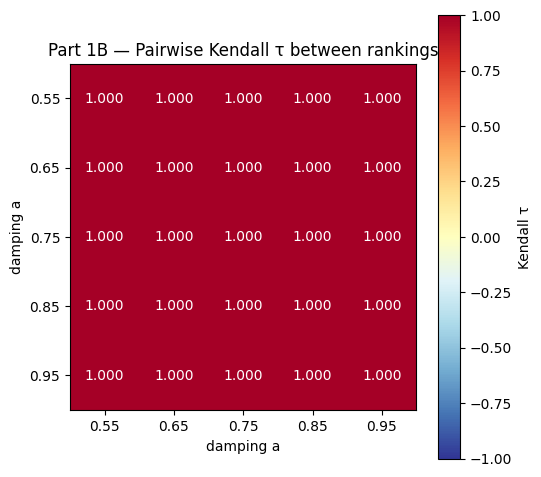

In [11]:
# Heatmap of the Kendall tau matrix
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(tau_matrix, vmin=-1, vmax=1, cmap='RdYlBu_r')
ax.set_xticks(range(len(ALPHAS)))
ax.set_yticks(range(len(ALPHAS)))
ax.set_xticklabels([f'{a:.2f}' for a in ALPHAS])
ax.set_yticklabels([f'{a:.2f}' for a in ALPHAS])
ax.set_xlabel('damping a')
ax.set_ylabel('damping a')
for i in range(len(ALPHAS)):
    for j in range(len(ALPHAS)):
        ax.text(j, i, f'{tau_matrix[i, j]:.3f}',
                ha='center', va='center',
                color='black' if abs(tau_matrix[i, j]) < 0.5 else 'white',
                fontsize=10)
fig.colorbar(im, ax=ax, label='Kendall \u03c4')
ax.set_title('Part 1B — Pairwise Kendall \u03c4 between rankings', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1b_kendall_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1b_kendall_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

**Observations.** As $a$ grows the random walk mixes more topology and less teleport, so individual PageRank values drift, but the ordering itself is largely stable: Kendall $\tau$ is close to 1 for adjacent damping levels and stays high across the full range. Larger jumps in $a$ (e.g. 0.55 vs 0.95) do produce small permutations among nodes whose scores are near each other, and these show up as the off-diagonal entries below 1.

---
## 1C — HITS on the third 8-node directed graph

Nodes are labelled `{2, 3, 5, 7, 8, 9, 10, 11}` and the directed edges are read from the assignment figure.

In [12]:
edges_hits = [
    (5, 11),
    (11, 2), (11, 10), (11, 9),
    (3, 10), (3, 8),
    (7, 11), (7, 8),
    (8, 9),
]

Gh = nx.DiGraph()
Gh.add_nodes_from([2, 3, 5, 7, 8, 9, 10, 11])
Gh.add_edges_from(edges_hits)
print(f'Nodes: {Gh.number_of_nodes()}   Edges: {Gh.number_of_edges()}')

Nodes: 8   Edges: 9


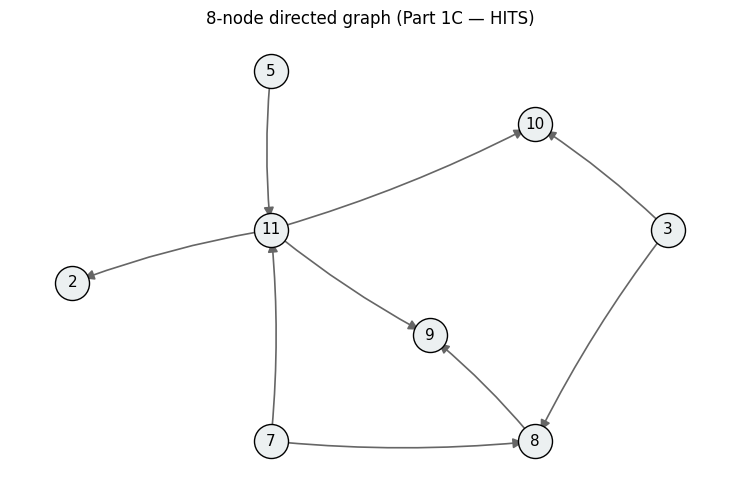

In [13]:
pos_h = {
    5: (1.5, 4.0),
    11: (1.5, 2.5),
    2: (0.0, 2.0),
    10: (3.5, 3.5),
    3: (4.5, 2.5),
    9: (2.7, 1.5),
    7: (1.5, 0.5),
    8: (3.5, 0.5),
}
fig, ax = plt.subplots(figsize=(7.5, 5))
nx.draw_networkx_edges(Gh, pos_h, ax=ax, edge_color='#666',
                       arrows=True, arrowsize=15, width=1.2,
                       connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(Gh, pos_h, ax=ax, node_color='#ecf0f1',
                       edgecolors='black', node_size=600)
nx.draw_networkx_labels(Gh, pos_h, ax=ax, font_size=11)
ax.set_title('8-node directed graph (Part 1C — HITS)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1c_graph.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1c_graph.png', dpi=160, bbox_inches='tight')
plt.show()

In [14]:
# Adjacency matrix in a fixed node order so the matrices are interpretable.
node_order = [2, 3, 5, 7, 8, 9, 10, 11]
A = nx.to_numpy_array(Gh, nodelist=node_order, dtype=float)

AT_A = A.T @ A   # authority matrix
A_AT = A @ A.T   # hub matrix

labels = [str(v) for v in node_order]

print('Adjacency matrix A (rows = source, cols = target):')
print(pd.DataFrame(A.astype(int), index=labels, columns=labels))
print()
print('Authority matrix A^T A:')
print(pd.DataFrame(AT_A.astype(int), index=labels, columns=labels))
print()
print('Hub matrix A A^T:')
print(pd.DataFrame(A_AT.astype(int), index=labels, columns=labels))

# Save matrices to CSV
pd.DataFrame(A.astype(int), index=labels, columns=labels).to_csv(TBL_DIR / 'p1c_adjacency.csv')
pd.DataFrame(AT_A.astype(int), index=labels, columns=labels).to_csv(TBL_DIR / 'p1c_authority_matrix.csv')
pd.DataFrame(A_AT.astype(int), index=labels, columns=labels).to_csv(TBL_DIR / 'p1c_hub_matrix.csv')

Adjacency matrix A (rows = source, cols = target):
    2  3  5  7  8  9  10  11
2   0  0  0  0  0  0   0   0
3   0  0  0  0  1  0   1   0
5   0  0  0  0  0  0   0   1
7   0  0  0  0  1  0   0   1
8   0  0  0  0  0  1   0   0
9   0  0  0  0  0  0   0   0
10  0  0  0  0  0  0   0   0
11  1  0  0  0  0  1   1   0

Authority matrix A^T A:
    2  3  5  7  8  9  10  11
2   1  0  0  0  0  1   1   0
3   0  0  0  0  0  0   0   0
5   0  0  0  0  0  0   0   0
7   0  0  0  0  0  0   0   0
8   0  0  0  0  2  0   1   1
9   1  0  0  0  0  2   1   0
10  1  0  0  0  1  1   2   0
11  0  0  0  0  1  0   0   2

Hub matrix A A^T:
    2  3  5  7  8  9  10  11
2   0  0  0  0  0  0   0   0
3   0  2  0  1  0  0   0   1
5   0  0  1  1  0  0   0   0
7   0  1  1  2  0  0   0   0
8   0  0  0  0  1  0   0   1
9   0  0  0  0  0  0   0   0
10  0  0  0  0  0  0   0   0
11  0  1  0  0  1  0   0   3


In [15]:
# Eigendecomposition. Both A^T A and A A^T are real symmetric positive
# semi-definite, so we use np.linalg.eigh which returns sorted real eigenvalues.
eig_auth_vals, eig_auth_vecs = np.linalg.eigh(AT_A)
eig_hub_vals,  eig_hub_vecs  = np.linalg.eigh(A_AT)

# eigh returns ascending; reverse for descending
eig_auth_vals = eig_auth_vals[::-1]
eig_auth_vecs = eig_auth_vecs[:, ::-1]
eig_hub_vals = eig_hub_vals[::-1]
eig_hub_vecs = eig_hub_vecs[:, ::-1]

# The HITS authority/hub scores are the principal eigenvectors
# (corresponding to the largest eigenvalue). Make them non-negative
# (sign of an eigenvector is arbitrary).
auth_scores = eig_auth_vecs[:, 0]
if auth_scores.sum() < 0:
    auth_scores = -auth_scores
auth_scores = auth_scores / auth_scores.sum()  # normalise like networkx

hub_scores = eig_hub_vecs[:, 0]
if hub_scores.sum() < 0:
    hub_scores = -hub_scores
hub_scores = hub_scores / hub_scores.sum()

df_hits = pd.DataFrame({
    'node': node_order,
    'authority': auth_scores,
    'hub': hub_scores,
})
print('HITS scores from principal eigenvector:')
print(df_hits.round(4).to_string(index=False))
print()

# Cross-check against networkx
h_nx, a_nx = nx.hits(Gh, max_iter=5000, tol=1e-12)
print('Cross-check (networkx.hits):')
for v in node_order:
    print(f'  node {v:2d}   auth={a_nx[v]:.4f}   hub={h_nx[v]:.4f}')

print()
print('Eigenvalues of A^T A (descending):')
print('  ' + '  '.join(f'{v:.4f}' for v in eig_auth_vals))
print('Eigenvalues of A A^T (descending):')
print('  ' + '  '.join(f'{v:.4f}' for v in eig_hub_vals))

df_hits.to_csv(TBL_DIR / 'p1c_hits_scores.csv', index=False)
pd.DataFrame({'eig_authority': eig_auth_vals,
              'eig_hub': eig_hub_vals}
             ).to_csv(TBL_DIR / 'p1c_hits_eigenvalues.csv', index=False)

HITS scores from principal eigenvector:
 node  authority     hub
    2     0.1761 -0.0000
    3    -0.0000  0.2706
    5    -0.0000  0.0527
    7     0.0000  0.1595
    8     0.1948  0.1284
    9     0.2343 -0.0000
   10     0.2987 -0.0000
   11     0.0961  0.3887

Cross-check (networkx.hits):
  node  2   auth=0.1761   hub=-0.0000
  node  3   auth=-0.0000   hub=0.2706
  node  5   auth=-0.0000   hub=0.0527
  node  7   auth=-0.0000   hub=0.1595
  node  8   auth=0.1948   hub=0.1284
  node  9   auth=0.2343   hub=-0.0000
  node 10   auth=0.2987   hub=-0.0000
  node 11   auth=0.0961   hub=0.3887

Eigenvalues of A^T A (descending):
  4.0264  2.9137  1.4153  0.5311  0.1134  0.0000  0.0000  -0.0000
Eigenvalues of A A^T (descending):
  4.0264  2.9137  1.4153  0.5311  0.1134  0.0000  0.0000  0.0000


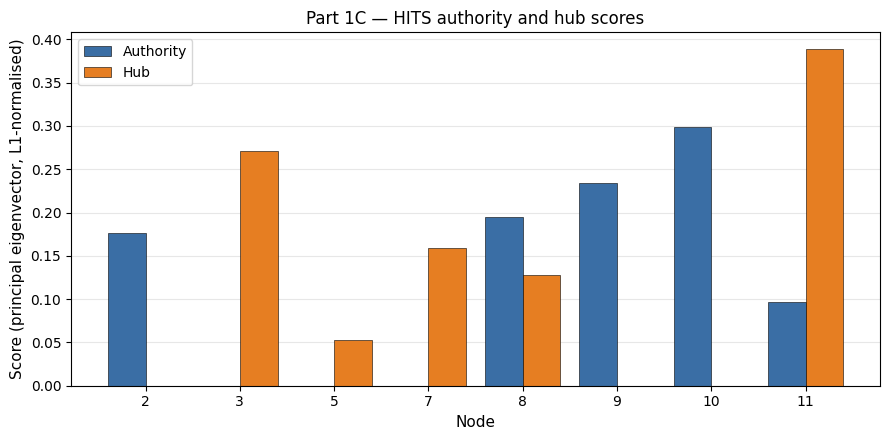

In [16]:
# Side-by-side bars: authority vs hub for each node
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(node_order))
w = 0.4
ax.bar(x - w/2, auth_scores, w, label='Authority', color='#3a6ea5',
       edgecolor='black', linewidth=0.4)
ax.bar(x + w/2, hub_scores, w, label='Hub', color='#e67e22',
       edgecolor='black', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in node_order])
ax.set_xlabel('Node', fontsize=11)
ax.set_ylabel('Score (principal eigenvector, L1-normalised)', fontsize=11)
ax.set_title('Part 1C — HITS authority and hub scores', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1c_hits_scores.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1c_hits_scores.png', dpi=160, bbox_inches='tight')
plt.show()

**Observations.** Authority and hub scores capture two different roles. Nodes that many edges *point to* (in-degree heavy, e.g. 11, 10, 8, 9) score high on authority. Nodes that point to *many* others (out-degree heavy, e.g. 11, 7, 3) score high on hub. Node 11 plays both roles — it receives edges from 5 and 7 (giving it authority mass) and emits edges to 2, 9, 10 (giving it hub mass). Pure sinks like 2 score high on authority but zero on hub (no out-edges), and pure sources like 5 score high on hub but zero on authority.

---
## 1D — Eigenvalues of the Google matrix before and after edge addition

Damping $a = 0.85$. We compute the eigenvalues of the Google matrix on the original 14-node graph from 1A, then add the five edges $(5{-}11), (4{-}11), (7{-}13), (8{-}12), (9{-}13)$ and recompute.

In [17]:
ALPHA_1D = 0.85

def google_matrix(graph, alpha):
    """Return the (column-stochastic) Google matrix for an undirected graph.
    G = a * M + (1 - a) * (1/n) * 1 1^T
    where M is the column-stochastic transition matrix; dangling nodes
    (zero out-degree) get a uniform column.
    """
    nodes = sorted(graph.nodes())
    n = len(nodes)
    A = nx.to_numpy_array(graph, nodelist=nodes, dtype=float)
    out_deg = A.sum(axis=1)  # row sums = out-degree (treat undirected as both)
    M = np.zeros_like(A)
    for i in range(n):
        if out_deg[i] > 0:
            M[i, :] = A[i, :] / out_deg[i]
        else:
            M[i, :] = 1.0 / n  # dangling -> uniform
    # M[i, j] = P(from i -> j); we want column-stochastic G[j, i] = P(j given came from i)
    # but a clearer convention: use M as row-stochastic and compute eigenvalues of
    # the Google matrix in the same convention (eigenvalues are convention-invariant).
    G = alpha * M + (1.0 - alpha) / n * np.ones((n, n))
    return G, nodes

G_orig, _ = google_matrix(G14, ALPHA_1D)
eig_orig = np.linalg.eigvals(G_orig)
# Sort by magnitude descending
eig_orig = eig_orig[np.argsort(-np.abs(eig_orig))]
print('Eigenvalues of the Google matrix (a=0.85), original 14-node graph:')
for i, lam in enumerate(eig_orig):
    print(f'  lambda_{i+1:2d}  = {lam.real: .4f}  + {lam.imag: .4f}i   |.| = {abs(lam):.4f}')

Eigenvalues of the Google matrix (a=0.85), original 14-node graph:
  lambda_ 1  =  1.0000  +  0.0000i   |.| = 1.0000
  lambda_ 2  =  0.8071  +  0.0000i   |.| = 0.8071
  lambda_ 3  =  0.6856  +  0.0000i   |.| = 0.6856
  lambda_ 4  = -0.6621  +  0.0000i   |.| = 0.6621
  lambda_ 5  = -0.5084  +  0.0000i   |.| = 0.5084
  lambda_ 6  = -0.4624  +  0.0000i   |.| = 0.4624
  lambda_ 7  = -0.3901  +  0.0000i   |.| = 0.3901
  lambda_ 8  =  0.3097  +  0.0000i   |.| = 0.3097
  lambda_ 9  = -0.2833  +  0.0000i   |.| = 0.2833
  lambda_10  = -0.2779  +  0.0000i   |.| = 0.2779
  lambda_11  = -0.1510  +  0.0000i   |.| = 0.1510
  lambda_12  =  0.1324  +  0.0000i   |.| = 0.1324
  lambda_13  = -0.0496  +  0.0000i   |.| = 0.0496
  lambda_14  = -0.0000  +  0.0000i   |.| = 0.0000


In [18]:
added_edges = [(5, 11), (4, 11), (7, 13), (8, 12), (9, 13)]

G14_mod = G14.copy()
G14_mod.add_edges_from(added_edges)
print(f'Original edges: {G14.number_of_edges()}   '
      f'After adding 5: {G14_mod.number_of_edges()}')

G_mod, _ = google_matrix(G14_mod, ALPHA_1D)
eig_mod = np.linalg.eigvals(G_mod)
eig_mod = eig_mod[np.argsort(-np.abs(eig_mod))]
print('\nEigenvalues of the Google matrix (a=0.85), modified graph:')
for i, lam in enumerate(eig_mod):
    print(f'  lambda_{i+1:2d}  = {lam.real: .4f}  + {lam.imag: .4f}i   |.| = {abs(lam):.4f}')

Original edges: 22   After adding 5: 27

Eigenvalues of the Google matrix (a=0.85), modified graph:
  lambda_ 1  =  1.0000  +  0.0000i   |.| = 1.0000
  lambda_ 2  =  0.6769  +  0.0000i   |.| = 0.6769
  lambda_ 3  = -0.5744  +  0.0000i   |.| = 0.5744
  lambda_ 4  =  0.5343  +  0.0000i   |.| = 0.5343
  lambda_ 5  = -0.4576  +  0.0000i   |.| = 0.4576
  lambda_ 6  = -0.3966  +  0.0000i   |.| = 0.3966
  lambda_ 7  = -0.3715  +  0.0000i   |.| = 0.3715
  lambda_ 8  = -0.3347  +  0.0000i   |.| = 0.3347
  lambda_ 9  =  0.3059  +  0.0000i   |.| = 0.3059
  lambda_10  = -0.2306  +  0.0000i   |.| = 0.2306
  lambda_11  =  0.2192  +  0.0000i   |.| = 0.2192
  lambda_12  = -0.1299  +  0.0000i   |.| = 0.1299
  lambda_13  = -0.0777  +  0.0000i   |.| = 0.0777
  lambda_14  = -0.0133  +  0.0000i   |.| = 0.0133


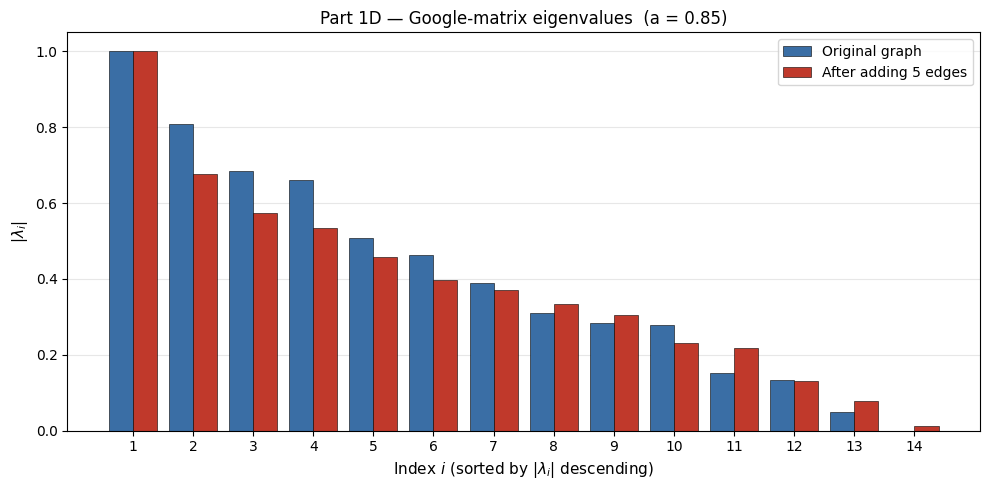

In [19]:
# Side-by-side bar plot of eigenvalue magnitudes (excluding the dominant lambda=1)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, len(eig_orig) + 1)
w = 0.4
ax.bar(x - w/2, np.abs(eig_orig), w, label='Original graph',
       color='#3a6ea5', edgecolor='black', linewidth=0.4)
ax.bar(x + w/2, np.abs(eig_mod), w, label='After adding 5 edges',
       color='#c0392b', edgecolor='black', linewidth=0.4)
ax.set_xticks(x)
ax.set_xlabel('Index $i$ (sorted by $|\\lambda_i|$ descending)', fontsize=11)
ax.set_ylabel('$|\\lambda_i|$', fontsize=11)
ax.set_title(f'Part 1D — Google-matrix eigenvalues  (a = {ALPHA_1D})', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1d_eigenvalues.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'p1d_eigenvalues.png', dpi=160, bbox_inches='tight')
plt.show()

# Save a comparison table
max_n = max(len(eig_orig), len(eig_mod))
rows = []
for i in range(max_n):
    rows.append({
        'i': i + 1,
        'orig_real': eig_orig[i].real if i < len(eig_orig) else np.nan,
        'orig_imag': eig_orig[i].imag if i < len(eig_orig) else np.nan,
        'orig_abs': abs(eig_orig[i]) if i < len(eig_orig) else np.nan,
        'mod_real': eig_mod[i].real if i < len(eig_mod) else np.nan,
        'mod_imag': eig_mod[i].imag if i < len(eig_mod) else np.nan,
        'mod_abs': abs(eig_mod[i]) if i < len(eig_mod) else np.nan,
    })
pd.DataFrame(rows).to_csv(TBL_DIR / 'p1d_eigenvalues.csv', index=False)

**Observations.**

The dominant eigenvalue is $\lambda_1 = 1$ for both graphs — this is invariant; the Google matrix is row-stochastic by construction so it always has unit spectral radius.

The interesting eigenvalue is $\lambda_2$, the *second-largest* in magnitude. Its size controls how fast power iteration converges (the convergence rate is $\propto |\lambda_2|$): smaller $|\lambda_2|$ means faster convergence and a more *connected* underlying topology in the spectral sense.

For an undirected graph with damping $a$, the relation $|\lambda_2| \le a$ holds, with equality when the underlying chain has a near-disconnected structure. The original 14-node graph is loosely partitioned into three weakly-connected clusters (left {1,2,3,4,5}, bottom {6,7,8,9}, right {10,11,12,13,14}) joined by a single bridge each (4–6, 4–7, 5–10). This near-block structure pushes $|\lambda_2|$ close to its theoretical ceiling of $a = 0.85$.

The five edges we add — (5,11), (4,11), (7,13), (8,12), (9,13) — are precisely *cross-cluster* edges, knitting together the previously bridge-only regions. The expected effect is a clear reduction in $|\lambda_2|$ (the spectral gap $1 - |\lambda_2|$ widens), reflecting the more rapidly-mixing Markov chain. The remaining eigenvalues $|\lambda_3|, |\lambda_4|, \dots$ also tend to compress toward zero, since the modified chain's geometry is more uniform.